In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
import time

# 6章演習問題

## (1) z変換

### (a) $x(n) = n\alpha^{n}\cdot u_0(n)$

z変換表のランプ関数のz変換と，z変換の性質の$\alpha^n$による乗算から，
\begin{align}
X(z) &= \frac{(\alpha^{-1}z)^{-1}}{(1-(\alpha^{-1}z)^{-1})^2}\\
&= \frac{\alpha z^{-1}}{(1-\alpha z^{-1})^2}\\
\end{align}

### (b) $x(n) = n!\cdot u_0(n)$

途中わかってないけど，z変換表から

$X(z)=e^z$

### (c) $x(n) = e^{j\omega n}\cdot u_0(n)$

\begin{align}
x(n) = \cos \omega n\cdot u_0(n) + j \sin \omega n\cdot u_0(n)
\end{align}

z変換表と線形性から，
\begin{align}
X(z) = \frac{1-z^{-1}\cos \omega}{1 - 2z^{-1}\cos \omega + z^{-2}} + j \frac{z^{-1}\sin \omega}{1 - 2z^{-1}\cos \omega +z^{-2}}
\end{align}



### (d) $x(n) = \sin\omega n \cdot u_0(n)$

表のままなので略

### (e) $x(n) = \cos \omega n\cdot u_0(n)$
表のままなので略

## (2) z変換

### (a) $x^{*}(n)$

$x(n)=a(n)+jb(n)$とおくと，

\begin{align}
X(z) &= \Sigma_{n=-\infty}^{\infty}x(n)z^{-n}\\
&= \Sigma_{n=-\infty}^{\infty}a(n)z^{-n} + j\Sigma_{n=-\infty}^{\infty}b(n)z^{-n}\\
&= A(z) + jB(z)
\end{align}

と表せる．$x^{*}(n)=a(n)-jb(n)$なので，これをz変換すると

\begin{align}
\Sigma_{n=-\infty}^{\infty}x^{*}(n)z^{-n}
&= \Sigma_{n=-\infty}^{\infty}a(n)z^{-n} - j\Sigma_{n=-\infty}^{\infty}b(n)z^{-n}\\
&= A(z) - jB(z)\\
&= X^{*}(z).
\end{align}


### (b) $x(-n)$

### (c) $n^{2}x(n)$

$n^{2}x(n) = n^2x(n) - nx(n) + nx(n)$と式変形すると，z変換表から

$z^2\frac{d^2}{dz^2}X(z)+z\frac{d}{dz}X(z)$

### (d) $[x(0), 0, x(1), 0, x(2), 0, x(3), 0, \cdots]$    (アップサンプリング)

数列を$y(m)$と置くと，
\begin{align}
\Sigma_{m=-\infty}^{\infty}y(m)z^{-m} &= \Sigma_{n=-\infty}^{\infty}x(n)z^{-2n}\\
&= X(z^2)
\end{align}

### (e) $[x(0), x(0)+x(1), x(0)+x(1)+x(2), \cdots, \Sigma_{k=0}^{n}x(k), \cdots ]$

ネットのz変換表から

$\frac{1}{1-z}X(z)$

## (3) z変換の性質

### 1. 線形性

\begin{align}
\Sigma_{n=-\infty}^{\infty}(a_1x_1(n)+a_2x_2(n))z^{-n}
&= \Sigma_{n=-\infty}^{\infty}a_1x_1(n)z^{-n} +\Sigma_{n=-\infty}^{\infty}a_2x_2(n)z^{-n}\\
&= a_1\Sigma_{n=-\infty}^{\infty}x_1(n)z^{-n} +a_2\Sigma_{n=-\infty}^{\infty}x_2(n)z^{-n}\\
&= a_1X_1(z) + a_2X_2(z)
\end{align}

### 2. 推移

\begin{align}
\Sigma_{n=0}^{\infty}x(n-m)z^{-n}
&= x(0)z^{-m} + x(1)z^{-(m+1)} + x(2)z^{-(m+2)} + x(3)z^{-(m+3)} + \cdots\\
&= z^{-m}(x(0) + x(1)z^{-1} + x(2)z^{-2} + x(3)z^{-3} + \cdots)\\
&= z^{-m}\Sigma_{n=0}^{\infty}x(n)z^{-n}\\
&= z^{-m}X(z)
\end{align}

### 3. $\alpha^{n}$による乗算

\begin{align}
\Sigma_{n=0}^{\infty}\alpha^{n}x(n)z^{-n}
&= \Sigma_{n=0}^{\infty}x(n)(\alpha^{-1}z)^{-n}\\
&= X(\alpha^{-1}z)
\end{align}

### 4. 微分

\begin{align}
X(z) &= x(0) + x(1)z^{-1} + x(2)z^{-2} + x(3)z^{-3} + \cdots,\\
\frac{dX(z)}{dz} &= -x(1)z^{-2} - 2x(2)z^{-3} - 3x(3)z^{-4} + \cdots,\\
-z\frac{dX(z)}{dz} &= x(1)z^{-1} + 2x(2)z^{-2} + 3x(3)z^{-3} + \cdots\\
&= \mathcal{Z}[nx(n)]
\end{align}

### 5. たたみ込み

\begin{align}
Y(z) &= \Sigma_{n=-\infty}^{\infty}\Sigma_{k=-\infty}^{\infty}h(k)x(n-k)z^{-n}\\
&= \Sigma_{n=-\infty}^{\infty}\Sigma_{k=-\infty}^{\infty}h(k)x(n-k)z^{-(n-k)}z^{-k}\\
&= \Sigma_{n=-\infty}^{\infty}H(z)x(n-k)z^{-(n-k)}\\
&= H(z)X(z)
\end{align}

### 6. 初期値定理

\begin{align}
\lim_{z \to \infty}X(z) &= \lim_{z \to \infty}\Sigma_{n=-\infty}^{\infty}x(n)z^{-n}\\
&= \lim_{z \to \infty}(x(0) + x(1)z^{-1} + x(2)z^{-2} + \cdots)\\
&= x(0)
\end{align}

### 7. 最終値定理

\begin{align}
\lim_{z \to 1}(1-z^{-1})X(z) &= \lim_{z \to 1}(X(z)-z^{-1}X(z))\\
&= \lim_{z \to 1}(\mathcal{Z}[x(n)]-\mathcal{Z}[x(n-1)])\\
&= \lim_{z \to 1}(x(0)(1-z^{-1}) + x(1)z^{-1}(1-z^{-1}) + x(2)z^{-2}(1-z^{-1}) + \cdots + x(n)z^{-n}(1-z^{-1}) + \cdots)\\
\end{align}


## (4)非再帰形フィルタ$h(n)$に入力$x(n)$が加えられた場合について

\begin{align}
h(n) &= [\underline{1}, 3, 3, 1]\\
x(n) &= [\underline{1}, -2, 3, 2]\\
\end{align}


### (a)出力$y(n)$を求めよ．


y(n) =  [ 1  1  0  6 13  9  2]


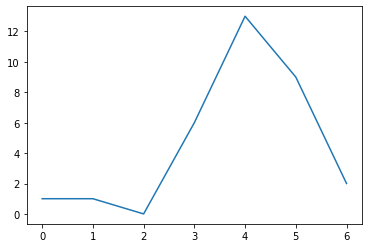

In [3]:
h = [1, 3, 3, 1]
x = [1, -2, 3, 2]

y = np.convolve(h, x, mode="full")

print("y(n) = ", y)

plt.plot(y)
plt.show()

### (b) $Y(z)=H(z)X(z)$の関係が成り立っていることを実際に確かめよ．

\begin{align}
H(z) &= 1 + 3z^{-1} + 3z^{-2} + z^{-2}\\
X(z) &= 1 - 2z^{-1} + 3z^{-2} + 2z^{-2}\\
Y(z) &= H(z)X(z) = (1 + 3z^{-1} + 3z^{-2} + z^{-2})(1 - 2z^{-1} + 3z^{-2} + 2z^{-2})\\
&= 1 + z^{-1} + 6z^{-3} + 13z^{-4} + 9z^{-5} + 2z^{-6}
\end{align}

(a)で求めた$y(n)$のz変換と一致する．

## (5) 次の1次差分再帰形フィルタについて

$y(n) = 0.5y(n-1)+0.5x(n)$

### (a)単位インパルス応答

\begin{align}
y(0) &= 0.5y(-1) + 0.5\delta(0) = 0.5\\
y(1) &= 0.5y(0) + 0.5\delta(1) = 0.5^2\\
y(2) &= 0.5y(1) + 0.5\delta(2) = 0.5^3\\
\vdots \\
y(n) &= 0.5^{n+1}, \quad n\ge 0\\
\end{align}

### (b)入力$x(n)=[\underline{1}, 1, 1, 1]$が入ってきたときの出力$y(n)$

\begin{align}
y(0) &= 0.5y(-1) + 0.5 = 0.5\\
y(1) &= 0.5y(0) + 0.5 = 0.5^2+0.5\\
y(2) &= 0.5y(1) + 0.5 = 0.5^3+0.5^2+0.5\\
y(3) &= 0.5y(2) + 0.5 = 0.5^4+0.5^3+0.5^2+0.5\\
y(4) &= 0.5y(3) = 0.5^5+0.5^4+0.5^3+0.5^2\\
y(5) &= 0.5y(4) = 0.5^6+0.5^5+0.5^4+0.5^3\\
\vdots
\end{align}

### (c) $Y(z)=H(z)X(z)$が成り立つことを確かめよ．

$H(z)$は単位インパルス応答をz変換して，$H(z)=\frac{0.5}{1-0.5z^{-1}}$，
$X(z)$は$x(n)=[1,1,1,1]=u_0(n)-u_0(n-5)$より，これをz変換して，
$X(z)=\frac{1-z^{-5}}{1-z^{-1}}$と表せる．

$Y(z)$は，差分方程式をz変換して，
\begin{align}
Y(z) &= 0.5z^{-1}Y(z) + 0.5X(z)\\
(1-0.5z^{-1})Y(z) &= 0.5X(z)\\
Y(z) &= \frac{0.5}{1-0.5z^{-1}}X(z)
\end{align}

## (6) 逆z変換

テイラー展開してべき級数展開法で求める．

### (a) $X(z)=(1+z^{-1})^N$

$(1 + z^{-1})^N = \Sigma_{k=0}^{N}{}_NC_kz^{-k}$とべき級数に展開できるので，
$x(n)={}_NC_n$

### (b) $X(z) = e^{1/z}$

$e^{1/z}=\Sigma_{k=0}^{\infty}\frac{z^{-k}}{n!}$と展開できるので，$x(n)=\frac{1}{n!}$



### (c) $X(z)=\log (1-z^{-1})$

$\log (1-z^{-1})=\Sigma_{k=0}^{\infty}\frac{(-1)^{k+1}}{k}z^{-k}$と展開できるので，$x(n)=\frac{(-1)^{n+1}}{n}$

### (d) $X(z)=\sin z^{-1}$

$\sin z^{-1} = z^{-1}-\frac{1}{3!}z^{-3}+\frac{1}{5!}z^{-5}-\frac{1}{7!}z^{-7}+\cdots$と展開できるので，
$x(n)=[0, 1, 0, -\frac{1}{3!}, 0, \frac{1}{5!}, 0, -\frac{1}{7!}, \cdots]$

### (e) $X(z)=\cos z^{-1}$

$\cos z^{-1} = 1-\frac{1}{2!}z^{-2}+\frac{1}{4!}z^{-4}-\frac{1}{6!}z^{-6}+\cdots$と展開できるので，
$x(n)=[1, 0, -\frac{1}{2!}, 0, \frac{1}{4!}, 0, -\frac{1}{6!}, 0, \cdots]$

## (7) 極と零点

## (8) 極と零点

### (a) $X(z)=\frac{1}{1-0.9z^{-1}+0.81z^{-2}}$

極：$0.9(1 \pm j\sqrt{3})$

零点：なし

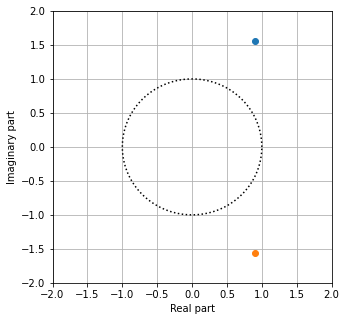

In [4]:
plt.figure(figsize=(5, 5))
plt.scatter(0.9, 0.9*np.sqrt(3))
plt.scatter(0.9, -0.9*np.sqrt(3))

theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), c="black", linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.grid()
plt.show()

### (b) $X(z)=\frac{1}{(1-0.5z^{-1})^{2}}$

極：0.5で重根

零点：なし

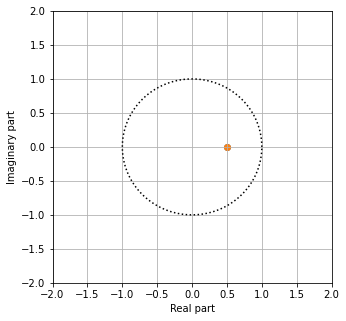

In [5]:
plt.figure(figsize=(5, 5))
plt.scatter(0.5, 0)
plt.scatter(0.5, 0)

theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), c="black", linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.grid()
plt.show()

### (c) $X(z)=\frac{z^{-3}-z^{-8}}{1-z^{-1}}$

極：1

零点:０, 1

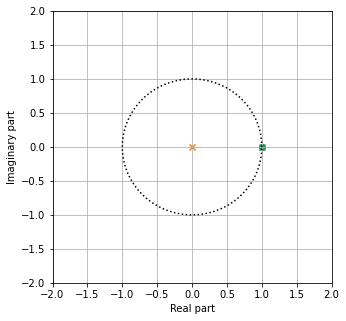

In [6]:
plt.figure(figsize=(5, 5))
plt.scatter(1, 0)
plt.scatter(0, 0, marker="x")
plt.scatter(1, 0, marker="x")

theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), c="black", linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.grid()
plt.show()

## (9) 周回積分を用いて$X(z)$の逆z変換を求めよ．

### (a) $X(z) = \frac{1-0.5z^{-1}}{1-0.5z^{-1}-0.5z^{-2}}$

$X(z)$の極は分母多項式=0を解いて，
\begin{align}
z^{-1} &= \frac{0.5\pm \sqrt{0.25-4\cdot (-0.5)}}{-1}\\
&= -0.5 \pm \sqrt{2.25}\\
&= -0.5 \pm 1.5\\
&=1.0, \quad 2.0
\end{align}

となるので，$X(z)$は次式に変形できる．
\begin{align}
X(z) &= \frac{1-0.5z^{-1}}{(1-z^{-1})(2-z^{-1})}\\
&= \frac{1-0.5z^{-1}}{2(1-z^{-1})(1-0.5z^{-1})}\\
&= \frac{1}{2}\frac{1}{1-z^{-1}}．\\
\end{align}

$X(z)z^{n-1}$は$z=1$で1位の極をもつ．$z=1$の留数は
\begin{align}
\rm{Res}(1) &= \lim_{z \to 1}(z-1)\frac{1}{2}\frac{1}{1-z^{-1}}z^{n-1}\\
&= \frac{1}{2}．
\end{align}

したがって，$x(n)=1/2,\quad n \ge 0$.

### (b) $X(z) = \frac{z^{-2}}{1-0.5z^{-1}-0.5z^{-2}}$

(a)で求めた結果から，$X(z)$は次式に変形できる．
\begin{align}
X(z) &= \frac{1}{2}\frac{z^{-2}}{(1-z^{-1})(1-0.5z^{-1})}．\\
\end{align}

$X(z)z^{n-1}$は$z=1$と$z=0.5$で1位の極をもつ．$z=1$と$z=0.5$の留数はそれぞれ
\begin{align}
\rm{Res}(1) &= \lim_{z \to 1}(z-1)\frac{1}{2}\frac{z^{-2}}{(1-z^{-1})(1-0.5z^{-1})}z^{n-1}\\
&= 1,\\
\rm{Res}(0.5) &= \lim_{z \to 0.5}(z-0.5)\frac{1}{2}\frac{z^{-2}}{(1-z^{-1})(1-0.5z^{-1})}z^{n-1}\\
&= \frac{0.5\cdot 0.5^{n-2}}{1-0.5^{-1}}\\
&= -0.5^{n-1}．\\
\end{align}

これらの和として，$x(n)=1-0.5^{n-1}，\quad n\ge 0$．

## (10) 逆z変換

$q=z^{-1}$とおく．
\begin{align}
X(q) &= x(0) + x(1)q + x(2)q^2 + x(3)q^3 + x(4)q^4 + x(5)q^5 + \cdots + x(n)q^n + \cdots,\\
\frac{d}{dq}X(q) &= x(1) + 2x(2)q + 3x(3)q^2 + 4x(4)q^3 + 5x(5)q^4 + \cdots + nx(n)q^(n-1) + \cdots,\\
\frac{d^2}{dq^2}X(q) &= 2x(2) + 3\cdot2x(3)q + 4\cdot3x(4)q^2 + 5\cdot4x(5)q^3 + \cdots + n(n-1)x(n)q^{(n-2)} + \cdots,\\
\frac{d^n}{dq^n}X(q) &= n!x(n) + \frac{(n+1)!}{1}x(n+1)q \cdots,\\
\frac{1}{n!}\frac{d^n}{dq^n}X(q) &= x(n) + \frac{(n+1)!}{n!}x(n+1)q \cdots,\\
\left.\frac{1}{n!}\frac{d^n}{dq^n}X(q)\right|_{q=0} &= x(n)
\end{align}